In [1]:
import io
import sys
import contextlib
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from math import factorial
from matplotlib.patches import Rectangle
from matplotlib.colors import LogNorm
from pdes.fokkerplanck2d.physics import symbolic_fokker_planck_1d, fokker_planck_exact_1d
from pdes.fokkerplanck2d.config import FokkerPlanck2DConfig
from common.pade_time_approx import _taylor_time_coeffs
plt.rcParams['text.usetex'] = (sys.platform == "darwin")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.serif'] = ['Computer Modern']
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath, amssymb}'
plt.rcParams['font.size'] = 9

colors = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4']
ink, muted, light_gray = '#0b0b0b', '#52514e', '#d9d8d4'

cfg = FokkerPlanck2DConfig()
T = cfg.duration
X_MIN, X_MAX = cfg.min_x, cfg.max_x
BOX = dict(theta=(cfg.theta_lb, cfg.theta_ub), kappa=(cfg.kappa_lb, cfg.kappa_ub))
print(f"T={T}, x in [{X_MIN},{X_MAX}], training box theta={BOX['theta']}, kappa={BOX['kappa']}")

T=2.0, x in [-8.0,8.0], training box theta=(0.5, 0.65), kappa=(0.8, 1.05)


In [2]:
# Only need the Taylor coeffs f_0..f_5 -- the [3/2] coefficients then follow from the same closed forms as compute_pade_time_32:
#   Delta = 4 f3^2 - 3 f2 f4,  b1 = (3 f2 f5 - 5 f3 f4) / (5 Delta),  b2 = (5 f4^2 - 4 f3 f5) / (20 Delta)
# Evaluated numerically instead of sp.simplify on the full approximant (~80s). We work with the unnormalised denominator
# D = 20 Delta + 4 (3 f2 f5 - 5 f3 f4) t + (5 f4^2 - 4 f3 f5) t^2, which has the same roots as Q but stays finite where
# Delta(x) = 0 (the coefficient singularity, where b1, b2 -> inf and t* -> 0).
xi, t_sym, theta_sym, kappa_sym, p_initial, pde_op = symbolic_fokker_planck_1d()
with contextlib.redirect_stdout(io.StringIO()):
    f_sym = _taylor_time_coeffs(p_initial, t_sym, pde_op, order=5)

# Strip the Gaussian envelope: f_k = g(x) * poly_k(x; theta, kappa). Cancels in b1, b2 and avoids underflow at |x| = 8
envelope = p_initial
poly_sym = [sp.expand(sp.simplify(fk / envelope)) for fk in f_sym]
_poly = sp.lambdify((xi, theta_sym, kappa_sym), poly_sym, modules='numpy')
_env = sp.lambdify(xi, envelope, modules='numpy')

def taylor_polys(x, theta, kappa):
    x = np.asarray(x, float)
    return [np.broadcast_to(np.asarray(v, float), np.broadcast(x, theta, kappa).shape) for v in _poly(x, theta, kappa)]

def pade32(x, theta, kappa):
    # Unnormalised [3/2]: numerator coeffs (times the envelope) and denominator coeffs d0 + d1 t + d2 t^2
    f0, f1, f2, f3, f4, f5 = taylor_polys(x, theta, kappa)
    d0 = 20 * (4 * f3**2 - 3 * f2 * f4)
    d1 = 4 * (3 * f2 * f5 - 5 * f3 * f4)
    d2 = 5 * f4**2 - 4 * f3 * f5
    n0 = f0 * d0
    n1 = f1 * d0 + f0 * d1
    n2 = (f2 / 2) * d0 + f1 * d1 + f0 * d2
    n3 = (f3 / 6) * d0 + (f2 / 2) * d1 + f1 * d2
    return (n0, n1, n2, n3), (d0, d1, d2)

def pade32_eval(x, t, theta, kappa):
    (n0, n1, n2, n3), (d0, d1, d2) = pade32(x, theta, kappa)
    return _env(x) * (n0 + n1 * t + n2 * t**2 + n3 * t**3) / (d0 + d1 * t + d2 * t**2)

for k, p in enumerate(poly_sym):
    print(f"f{k}/g: degree {sp.Poly(p, xi).degree()} in x")

f0/g: degree 0 in x
f1/g: degree 2 in x
f2/g: degree 4 in x
f3/g: degree 6 in x
f4/g: degree 8 in x
f5/g: degree 10 in x


In [3]:
# Sanity check: for small t, P_[3/2] should match the degree-5 Taylor poly up to O(t^6), and the exact OU density inside the training box
xs = np.linspace(X_MIN, X_MAX, 401)
th0, ka0 = 0.55, 0.9
fs = taylor_polys(xs, th0, ka0)
for tt in [1e-1, 5e-2, 2.5e-2]:
    taylor = _env(xs) * sum(fk * tt**k / factorial(k) for k, fk in enumerate(fs))
    print(f"t={tt:<7} max|P - Taylor5| = {np.max(np.abs(pade32_eval(xs, tt, th0, ka0) - taylor)):.3e}")
for tt in [0.5, 1.0, 2.0]:
    ex = fokker_planck_exact_1d(xs, tt, th0, ka0)
    print(f"t={tt:<4} rel-L2(P, exact) = {np.linalg.norm(pade32_eval(xs, tt, th0, ka0) - ex) / np.linalg.norm(ex):.3e}")

t=0.1     max|P - Taylor5| = 3.809e-08
t=0.05    max|P - Taylor5| = 6.058e-10
t=0.025   max|P - Taylor5| = 9.539e-12
t=0.5  rel-L2(P, exact) = 2.182e-04
t=1.0  rel-L2(P, exact) = 5.885e-03
t=2.0  rel-L2(P, exact) = 7.247e-02


In [4]:
# Pole set for a given (theta, kappa): real roots of d0 + d1 t + d2 t^2 in (0, T] at each x. Closed-form roots on a fine
# x grid, so there's no t-grid resolution involved. min Q uses the normalised Q = D/d0, checked at the endpoints and the interior vertex.
NX = 3201
x_grid = np.linspace(X_MIN, X_MAX, NX)

def real_roots_in_horizon(x, theta, kappa, t_max=T):
    # Returns (r_minus, r_plus) with NaN for roots that are complex or outside (0, t_max]
    _, (d0, d1, d2) = pade32(x, theta, kappa)
    with np.errstate(divide='ignore', invalid='ignore'):
        disc = d1**2 - 4 * d0 * d2
        sq = np.sqrt(np.where(disc >= 0, disc, np.nan))
        # Stable quadratic roots (avoid cancellation when d2 ~ 0)
        q = -0.5 * (d1 + np.sign(d1) * sq)
        r1, r2 = q / d2, d0 / q
    roots = np.stack([r1, r2])
    roots = np.where((roots > 0) & (roots <= t_max), roots, np.nan)
    return np.sort(roots, axis=0)

P_MAX = fokker_planck_exact_1d(x_grid, 0.0, 0.5, 1.0).max()  # peak of the IC, scale for residues

def pole_residues(x, theta, kappa, t_max=T):
    # Residue of P at each real pole in (0, t_max], relative to the IC peak: |N(t*) / D'(t*)| / max p0
    (n0, n1, n2, n3), (d0, d1, d2) = pade32(x, theta, kappa)
    r = real_roots_in_horizon(x, theta, kappa, t_max)
    with np.errstate(divide='ignore', invalid='ignore'):
        res = np.abs(_env(x) * (n0 + n1 * r + n2 * r**2 + n3 * r**3) / (d1 + 2 * d2 * r)) / P_MAX
    return r, res

def pole_summary(theta, kappa, x=x_grid, t_max=T):
    # (has_pole, earliest t*, largest relative residue) over all x
    r, res = pole_residues(x, theta, kappa, t_max)
    if not np.isfinite(r).any():
        return False, np.nan, np.nan
    return True, np.nanmin(r), np.nanmax(res)

def min_Q(theta, kappa, x=x_grid, t_max=T):
    _, (d0, d1, d2) = pade32(x, theta, kappa)
    with np.errstate(divide='ignore', invalid='ignore'):
        b1, b2 = d1 / d0, d2 / d0
        tv = np.clip(-b1 / (2 * b2), 0.0, t_max)
        cand = np.stack([np.ones_like(b1), 1 + b1 * t_max + b2 * t_max**2, 1 + b1 * tv + b2 * tv**2])
    return np.nanmin(cand)

for th, ka in [(0.5, 0.8), (0.5, 1.05), (0.65, 0.8), (0.65, 1.05), (0.45, 1.05), (0.70, 0.8), (0.8, 0.8)]:
    hit, t0, rmax = pole_summary(th, ka)
    print(f"theta={th:<5} kappa={ka:<5} pole={str(hit):<5} earliest t*={t0:.4f}  max rel. residue={rmax:.2e}  min Q={min_Q(th, ka):+.3e}")

theta=0.5   kappa=0.8   pole=False earliest t*=nan  max rel. residue=nan  min Q=+4.669e-01
theta=0.5   kappa=1.05  pole=False earliest t*=nan  max rel. residue=nan  min Q=+8.125e-01
theta=0.65  kappa=0.8   pole=False earliest t*=nan  max rel. residue=nan  min Q=+9.169e-02
theta=0.65  kappa=1.05  pole=False earliest t*=nan  max rel. residue=nan  min Q=+6.863e-01
theta=0.45  kappa=1.05  pole=True  earliest t*=0.0047  max rel. residue=3.44e-04  min Q=-6.780e+02
theta=0.7   kappa=0.8   pole=True  earliest t*=0.9993  max rel. residue=1.46e+00  min Q=-1.306e-01
theta=0.8   kappa=0.8   pole=True  earliest t*=0.1798  max rel. residue=3.37e+00  min Q=-2.331e+00


In [5]:
# Two kinds of poles show up in (0, T], both case (a) of the paper's [2,1] failure cases (pole inside the horizon), with Delta
# playing the role of f_2:
#   bulk poles (high theta, low kappa): near x ~ -0.3 where the density is large, t* = O(1), rel. residue up to O(1)
#   tail poles (low theta, high kappa): left tail x <~ -2.5, t* = O(1), rel. residue <~ 1e-3 (<= 3e-4 at kappa=1.05)
# Same mechanism, only the location differs -- tail residues are small because the Gaussian IC is tiny there. Each pole curve
# t*(x; theta) starts at a case (b) point (t* = 0, Delta = 0, pole-zero near cancellation, residue ~1e-20) and becomes a case (a)
# pole as it rises into the horizon, e.g. theta=0.45, kappa=1.05: residue goes from 8e-20 at t*=0.005 (x=-3.66) to 7e-6 at
# t*~1.0 (x=-3.34). Case (c) (coefficient singularity) didn't show up in this scan.
# All of these make L_r unbounded, but the bulk poles also wreck the warm start itself, so panel (a) of the figure below is
# coloured by the largest residue instead of t* (min_x t* is dominated by the harmless case (b) endpoints).
thetas = np.linspace(0.2, 1.0, 161)
kappas = np.linspace(0.5, 1.5, 161)
x_scan = np.linspace(X_MIN, X_MAX, 1201)
summ = [[pole_summary(th, ka, x=x_scan) for th in thetas] for ka in kappas]  # rows: kappa, cols: theta
HIT = np.array([[s[0] for s in row] for row in summ])
RES = np.array([[s[2] for s in row] for row in summ])

# Training-box check at the fine x grid
box_th = np.linspace(*BOX['theta'], 31)
box_ka = np.linspace(*BOX['kappa'], 31)
box_minQ = np.array([[min_Q(th, ka) for th in box_th] for ka in box_ka])
box_hits = np.array([[pole_summary(th, ka)[0] for th in box_th] for ka in box_ka])
i, j = np.unravel_index(box_minQ.argmin(), box_minQ.shape)
print(f"training box: {box_hits.sum()} / {box_hits.size} (theta,kappa) pairs with a pole in (0,T]")
print(f"training box: min Q = {box_minQ.min():.3e} at theta={box_th[j]:.3f}, kappa={box_ka[i]:.3f}")

# Pole-free kappa interval along each theta edge of the box, and pole-free theta interval along each kappa edge
def free_interval(vals, hit, lo, hi):
    below = vals[(vals < lo) & hit]
    above = vals[(vals > hi) & hit]
    return (below.max() if below.size else np.nan, above.min() if above.size else np.nan)

ka_fine = np.linspace(0.5, 1.5, 2001)
th_fine = np.linspace(0.2, 1.0, 1601)
for th in BOX['theta']:
    hit = np.array([pole_summary(th, ka)[0] for ka in ka_fine])
    print(f"theta={th}: nearest poles at kappa ~ {free_interval(ka_fine, hit, *BOX['kappa'])}   (box kappa {BOX['kappa']})")
for ka in BOX['kappa']:
    hit = np.array([pole_summary(th, ka)[0] for th in th_fine])
    print(f"kappa={ka}: nearest poles at theta ~ {free_interval(th_fine, hit, *BOX['theta'])}   (box theta {BOX['theta']})")

training box: 0 / 961 (theta,kappa) pairs with a pole in (0,T]
training box: min Q = 9.169e-02 at theta=0.650, kappa=0.800


theta=0.5: nearest poles at kappa ~ (0.6875, 1.068)   (box kappa (0.8, 1.05))


theta=0.65: nearest poles at kappa ~ (0.7855000000000001, 1.218)   (box kappa (0.8, 1.05))


kappa=0.8: nearest poles at theta ~ (0.2805, 0.674)   (box theta (0.5, 0.65))


kappa=1.05: nearest poles at theta ~ (0.48300000000000004, nan)   (box theta (0.5, 0.65))


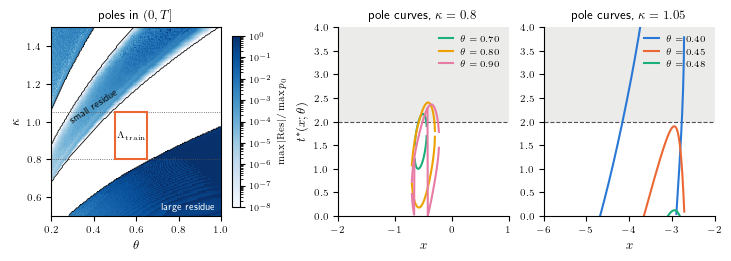

In [25]:
slices = [  # (kappa, thetas) for panels (b) and (c)
    (0.80, [0.60, 0.65, 0.70, 0.80, 0.90]),
    (1.05, [0.40, 0.45, 0.48, 0.50, 0.60]),
]

fig, axes = plt.subplots(1, 3, figsize=(7.2, 2.5), constrained_layout=True)

# (a) largest relative residue over (theta, kappa), white = no pole in (0, T]
ax = axes[0]
pc = ax.pcolormesh(thetas, kappas, np.ma.masked_invalid(np.where(HIT, np.maximum(RES, 1e-12), np.nan)),
                   cmap='Blues', norm=LogNorm(1e-8, 1e0), shading='auto', rasterized=True)
ax.contour(thetas, kappas, HIT.astype(float), levels=[0.5], colors=ink, linewidths=0.6)
ax.add_patch(Rectangle((BOX['theta'][0], BOX['kappa'][0]), np.diff(BOX['theta'])[0], np.diff(BOX['kappa'])[0],
                       fill=False, edgecolor=colors[1], linewidth=1.5, zorder=5))
for ka, _ in slices:
    ax.axhline(ka, color=muted, lw=0.6, ls=':')
ax.text(np.mean(BOX['theta']), np.mean(BOX['kappa']), r'$\Lambda_{\mathrm{train}}$', color=ink, fontsize=7, ha='center', va='center')
ax.text(0.97, 0.53, 'large residue', color='white', fontsize=7, ha='right')
ax.text(0.40, 1.08, 'small residue', color=ink, fontsize=7, rotation=33, ha='center', va='center')
ax.set_xlabel(r'$\theta$')
ax.set_ylabel(r'$\kappa$')
ax.set_title(r'poles in $(0,T]$', fontsize=9)
cb = fig.colorbar(pc, ax=ax, pad=0.02, fraction=0.05)
cb.set_label(r'$\max |\mathrm{Res}| / \max p_0$', fontsize=7)
cb.ax.tick_params(labelsize=6)

# (b), (c) pole curves t*(x; theta) at fixed kappa -- drawn past T so admissible thetas still show their pole beyond the horizon
t_show = 2.0 * T
for ax, (ka, ths), tag in zip(axes[1:], slices, 'bc'):
    ax.axhspan(T, t_show, color=light_gray, alpha=0.5, lw=0)
    ax.axhline(T, color=muted, lw=0.8, ls='--')
    for c, th in zip(colors, ths):
        r = real_roots_in_horizon(x_grid, th, ka, t_max=t_show)
        if not np.isfinite(r).any():
            continue
        for k in range(2):
            ax.plot(x_grid, r[k], color=c, lw=1.5, label=rf'$\theta={th:.2f}$' if k == 0 else None)
    ax.set_ylim(0, t_show)
    ax.set_xlabel(r'$x$')
    if tag == 'b':
        ax.set_ylabel(r'$t^*(x;\theta)$')
    ax.set_title(rf'pole curves, $\kappa={ka}$', fontsize=9)
    ax.legend(fontsize=6.5, frameon=False, loc='upper right', handlelength=1.6)
axes[1].set_xlim(-2.0, 1.0)
axes[2].set_xlim(-6.0, -2.0)

for ax in axes:
    ax.tick_params(labelsize=7)
for ax in axes[1:]:
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)

plt.savefig('./figs/poles/fokkerplanck_pade_poles.pdf', dpi=800, bbox_inches='tight')
plt.savefig('./figs/poles/fokkerplanck_pade_poles.png', dpi=300, bbox_inches='tight')
plt.show()

non-admissible (theta, kappa) = (0.8, 0.8): pole t* = 1.7992 at x = -0.295, relative residue 3.37e+00
all poles at x = -0.295: [1.67677857 1.79917208]


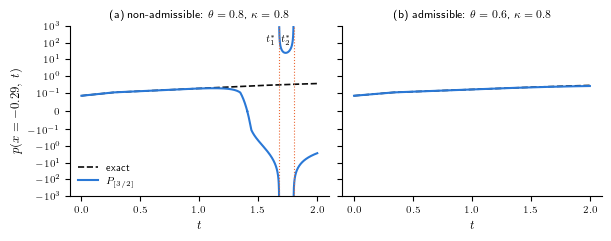

In [8]:
# Non-admissible (theta, kappa) just outside the box: take the x whose pole in (0.5, T) has the largest residue and compare
# P_[3/2](x, .) against the exact OU density there, next to an admissible pair at the same x. y-axis is symlog (linear for |p| < 0.1).
# Near t*, P ~ Res/(t - t*), so the squared residual blows up like (t - t*)^-4.
BAD = (0.80, 0.80)
GOOD = (0.60, 0.80)
r, res = pole_residues(x_grid, *BAD)
res = np.where((r > 0.5) & (r < T), res, np.nan)
k, ix = np.unravel_index(np.nanargmax(res), res.shape)
x_star, t_star = x_grid[ix], r[k, ix]
print(f"non-admissible (theta, kappa) = {BAD}: pole t* = {t_star:.4f} at x = {x_star:.3f}, relative residue {res[k, ix]:.2e}")

tt = np.linspace(0, T, 4001)
fig, axes = plt.subplots(1, 2, figsize=(6.0, 2.3), constrained_layout=True, sharey=True)
for ax, (th, ka), tag, title in [(axes[0], BAD, 'a', 'non-admissible'), (axes[1], GOOD, 'b', 'admissible')]:
    P = pade32_eval(x_star, tt, th, ka)
    P = np.where(np.abs(np.diff(np.sign(P), prepend=np.sign(P[0]))) > 0, np.nan, P)  # break the line across each pole
    ax.plot(tt, fokker_planck_exact_1d(x_star, tt, th, ka), color=ink, lw=1.2, ls='--', label='exact')
    ax.plot(tt, P, color=colors[0], lw=1.5, label=r'$P_{[3/2]}$')
    if tag == 'a':
        poles_here = real_roots_in_horizon(np.array([x_star]), th, ka)[:, 0]
        for k_p, tp in enumerate(poles_here[np.isfinite(poles_here)]):
            ax.axvline(tp, color=colors[1], lw=0.8, ls=':')
            ax.text(tp - 0.03, 0.95, rf'$t^*_{k_p + 1}$', color=ink, fontsize=7, ha='right', va='top', transform=ax.get_xaxis_transform())
        print(f"all poles at x = {x_star:.3f}: {poles_here}")
    ax.set_yscale('symlog', linthresh=0.1)
    ax.set_ylim(-1e3, 1e3)
    ax.set_xlabel(r'$t$')
    ax.set_title(rf'({tag}) {title}: $\theta={th}$, $\kappa={ka}$', fontsize=8)
    ax.tick_params(labelsize=7)
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
axes[0].set_ylabel(rf'$p(x={x_star:.2f},\,t)$')
axes[0].legend(fontsize=7, frameon=False, loc='lower left')
plt.savefig('./figs/poles/fokkerplanck_pade_pole_slice.pdf', dpi=800, bbox_inches='tight')
plt.savefig('./figs/poles/fokkerplanck_pade_pole_slice.png', dpi=300, bbox_inches='tight')
plt.show()